## Mari Mughdusyan
LAMC VOC ED_369CE_27696SP26M

# Cell Cancer Classification Project

## Overview
This project builds an end-to-end pipeline to classify cervical cells 
into four cancer status categories: negative, positive, atypical, and suspicious.

## Dataset
Two datasets are used:
- Dataset 1: 100 cell samples with numeric measurements (atypicality score, 
  nucleus-to-cytoplasm ratio, nuclear area, cytoplasm area) and their category labels.
- Dataset 2: 200 cell images paired with their ground truth segmentation masks,
  used to train the segmentation model.

## Pipeline
The project consists of two chained models:

1. Segmentation Model
   Takes a raw cell image as input and predicts a segmentation mask.
   The mask separates the nucleus from the cytoplasm and background.
   From the mask, three numeric measurements are extracted:
   nuclear area, cytoplasm area and nc ratio.

2. Classification Model
   Takes the three numeric measurements as input and predicts 
   the cancer status category. Three models were tested:
   Random Forest, SVM, and KNN — all achieving 0.75 accuracy.
   Random Forest was selected as the final model.

## Goal
Given only a raw cell image, the pipeline predicts the cancer status
of the cell. The prediction is validated against the known labels 
from Dataset 1. 

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### The data contains 100 images of cells labeled in four categoriesbased on their cancer status: positive, negative, atypical, and suspicious.

In [100]:
import pickle
import os
from PIL import Image

# ── Load the pickle file ──────────────────────────────────────────
with open('specimens_toy_data.pkl', 'rb') as f:
    raw = pickle.load(f)

# ── Two clean variables ───────────────────────────────────────────
# images: dict  →  { 'neg': [...], 'pos': [...], 'aty': [...], 'sus': [...] }
# Each value is a list of 25 images, every image is a (44, 34, 3) numpy array
images  = {cat: raw[cat]['imgs']     for cat in raw}

df = pd.concat(
    [raw[cat]['metadata'].assign(category=cat) for cat in raw],
    ignore_index=True
)

df.head()

,aty,nc_ratio,nuclear_area,cyto_area,category
0,0.057022,0.141928,7221.0,43657.0,neg
1,0.037513,0.175625,7597.0,35660.0,neg
2,0.056971,0.150782,7442.0,41914.0,neg
3,0.077020,0.182437,8177.0,36644.0,neg
4,0.111039,0.183712,8696.0,38639.0,neg


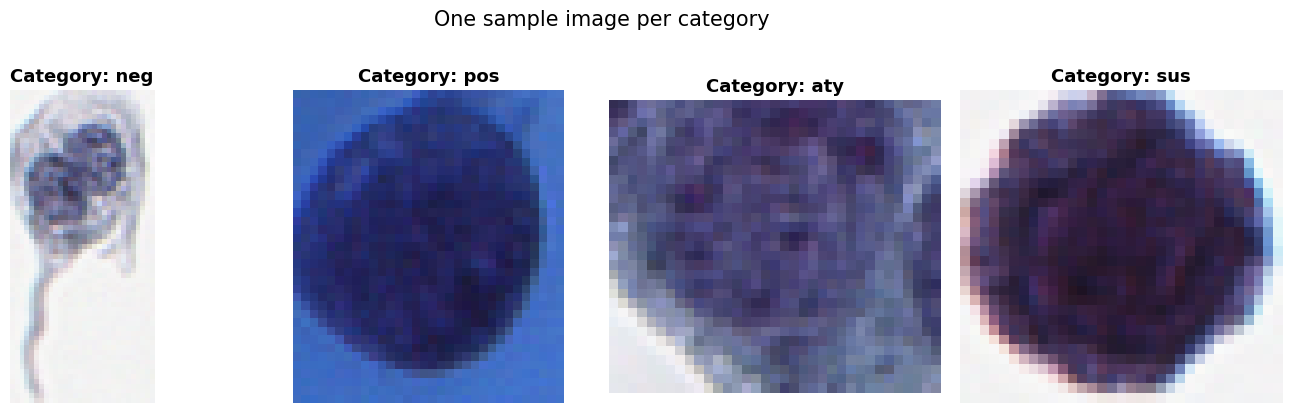

In [155]:
# ── Display one image per category ───────────────────────────────

CATEGORIES = list(raw.keys()) 
fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(14, 4))

for ax, cat in zip(axes, CATEGORIES):
    ax.imshow(images[cat][9])
    ax.set_title(f'Category: {cat}', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('One sample image per category', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [102]:
# ── Summary statistics per category ──────────────────────────────
df.groupby('category')[['aty','nc_ratio']].describe().round(3)

aty                                                  nc_ratio  \
         count   mean    std    min    25%    50%    75%    max    count   
category                                                                   
aty       25.0  0.188  0.233  0.033  0.049  0.094  0.137  0.956     25.0   
neg       25.0  0.075  0.054  0.017  0.044  0.057  0.076  0.250     25.0   
pos       25.0  0.346  0.295  0.051  0.157  0.187  0.505  0.994     25.0   
sus       25.0  0.300  0.281  0.064  0.103  0.173  0.355  0.997     25.0   

                                                           
           mean    std    min    25%    50%    75%    max  
category                                                   
aty       0.250  0.116  0.153  0.174  0.223  0.281  0.701  
neg       0.185  0.041  0.133  0.149  0.184  0.204  0.293  
pos       0.488  0.088  0.426  0.430  0.463  0.500  0.824  
sus       0.397  0.099  0.301  0.322  0.383  0.425  0.704

In [103]:
df.groupby('category')[['nuclear_area','cyto_area']].describe().round(3)

nuclear_area                                                          \
                count      mean       std      min      25%      50%      75%   
category                                                                        
aty              25.0  10887.32  6209.300   4669.0   7749.0   9640.0  11881.0   
neg              25.0   8636.76  1808.369   6593.0   6878.0   8177.0  10248.0   
pos              25.0  23122.24  5677.599  14985.0  20740.0  21532.0  23401.0   
sus              25.0  18822.16  6134.854  12400.0  15150.0  16981.0  19764.0   

                  cyto_area                                                 \
              max     count      mean       std      min      25%      50%   
category                                                                     
aty       36462.0      25.0  32373.12  8508.879  13948.0  25610.0  33588.0   
neg       12422.0      25.0  38409.00  4987.574  24338.0  36644.0  39692.0   
pos       44264.0      25.0  24053.52  4968.342   9452.0  22868.0  24242.0   
sus       36593.0      25.0  28146.04  5021.007  15401.0  25702.0  28212.0   

                            
              75%      max  
category                    
aty       39739.0  43741.0  
neg       41581.0  45413.0  
pos       27333.0  31119.0  
sus       30814.0  37861.0

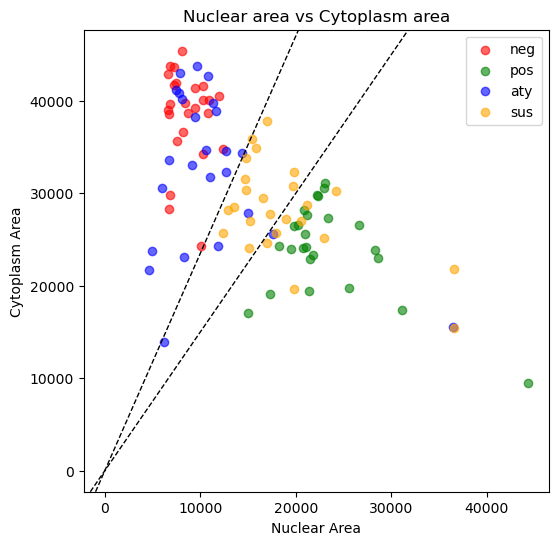

In [104]:
plt.figure(figsize=(6,6))

colors = {'pos':'green', 'neg':'red', 'aty':'blue', 'sus':'orange'}

for i in df['category'].unique():
    subset = df[df['category'] == i]
    
    plt.scatter(subset['nuclear_area'], 
                subset['cyto_area'],
                color=colors.get(i, 'gray'),
                label=i,
                alpha=0.6)
# plt.axhline(y=25000, color='black', linestyle='--', linewidth=1)  # horizontal
# plt.axvline(x=15000, color='black', linestyle='--', linewidth=1)  # vertical
plt.axline((0, 0), slope=1.5, color='black', linestyle='--', linewidth=1)
plt.axline((0, 0), slope=2.35, color='black', linestyle='--', linewidth=1)

plt.xlabel('Nuclear Area')
plt.ylabel('Cytoplasm Area')
plt.title('Nuclear area vs Cytoplasm area')
plt.legend()
plt.show()

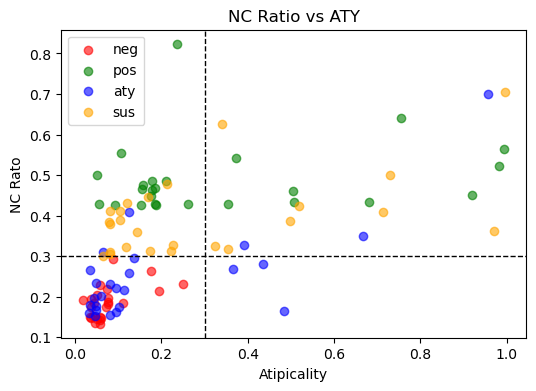

In [105]:
plt.figure(figsize=(6,4))

colors = {'pos':'green', 'neg':'red', 'aty':'blue', 'sus':'orange'}

for i in df['category'].unique():
    subset = df[df['category'] == i]
    
    plt.scatter(subset['aty'], 
                subset['nc_ratio'],
                color=colors.get(i, 'gray'),
                label=i,
                alpha=0.6)
plt.axhline(y=0.3, color='black', linestyle='--', linewidth=1)  # horizontal
plt.axvline(x=0.3, color='black', linestyle='--', linewidth=1)  # vertical


plt.xlabel('Atipicality')
plt.ylabel('NC Rato')
plt.title('NC Ratio vs ATY')
plt.legend()
plt.show()

The graph above shows that if Atipicality score high the result is NOT negative but in low atipicality we see that the result can be both positive and negative

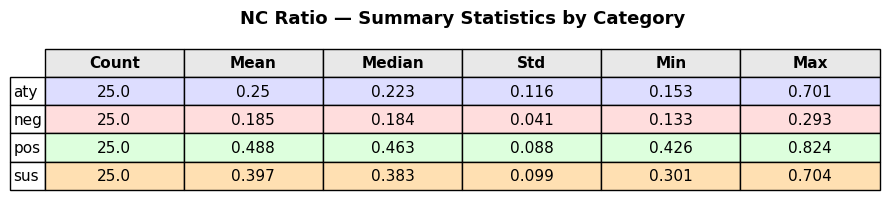

In [106]:
import matplotlib.patches as mpatches
from IPython.display import display

# --- 1. Styled summary table ---
stats = df.groupby('category')['nc_ratio'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    Min='min',
    Max='max'
).round(3)

# Color each row by category
colors_map = {'neg': '#fdd', 'aty': '#ddf', 'sus': '#ffe0b2', 'pos': '#dfd'}
row_colors = [[colors_map.get(cat, '#fff')] * len(stats.columns) 
              for cat in stats.index]

fig, ax = plt.subplots(figsize=(9, 2.2))
ax.axis('off')
table = ax.table(
    cellText=stats.values,
    rowLabels=stats.index,
    colLabels=stats.columns,
    cellLoc='center',
    loc='center',
    cellColours=row_colors
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Bold the header
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('#e8e8e8')

plt.title('NC Ratio — Summary Statistics by Category', 
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

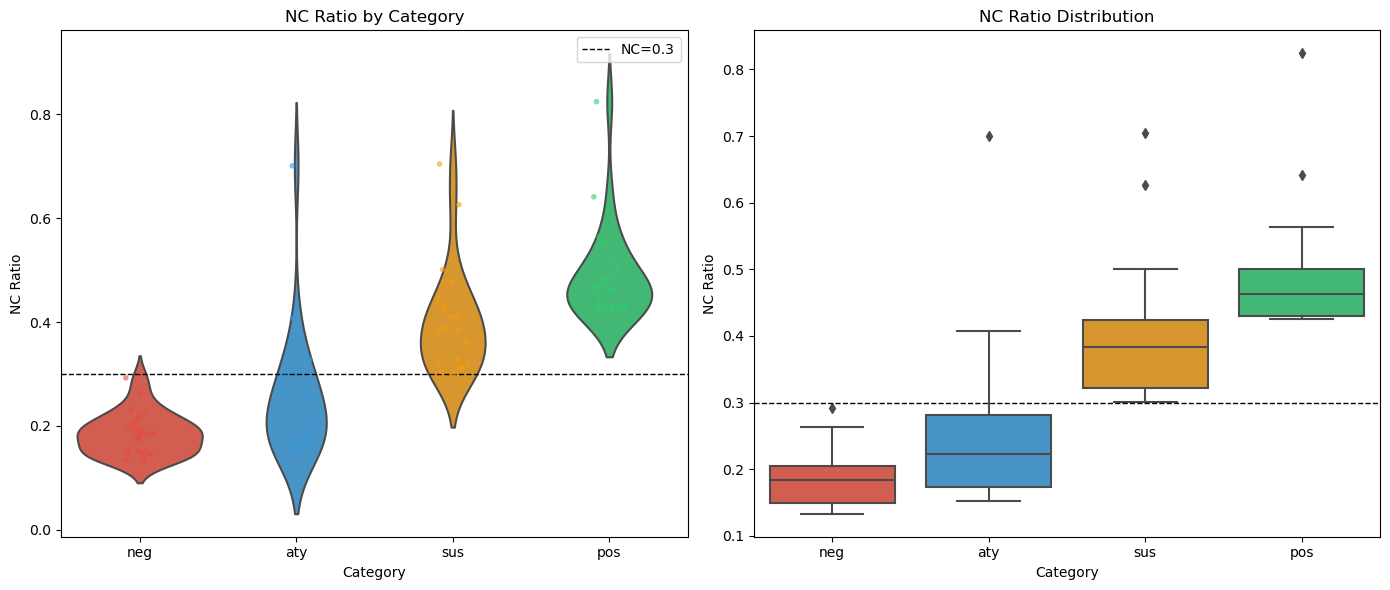

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define order and colors matching your categories
order = ['neg', 'aty', 'sus', 'pos']
palette = {'neg': '#e74c3c', 'aty': '#3498db', 'sus': '#f39c12', 'pos': '#2ecc71'}

# --- Plot 1: Violin + Strip ---
sns.violinplot(data=df, x='category', y='nc_ratio',
               order=order, palette=palette,
               inner=None, ax=axes[0])
sns.stripplot(data=df, x='category', y='nc_ratio',
              order=order, palette=palette,
              size=4, jitter=True, alpha=0.6, ax=axes[0])
axes[0].axhline(y=0.3, color='black', linestyle='--', linewidth=1, label='NC=0.3')
axes[0].set_title('NC Ratio by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('NC Ratio')
axes[0].legend()

# --- Plot 2: Box plot with stats ---
sns.boxplot(data=df, x='category', y='nc_ratio',
            order=order, palette=palette, ax=axes[1])
axes[1].axhline(y=0.3, color='black', linestyle='--', linewidth=1)
axes[1].set_title('NC Ratio Distribution')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('NC Ratio')

plt.tight_layout()
plt.show()

### Train Test split

In [108]:
X = df[['aty', 'nc_ratio', 'nuclear_area', 'cyto_area']]
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 80
Test size: 20


## Random Forest

In [109]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [151]:
rf_model = RandomForestClassifier(n_estimators = 14, random_state = 42, class_weight={'neg': 3, 'pos': 1, 'aty': 1, 'sus': 1})
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
random_forest_accuracy = accuracy_score(y_test, y_pred)
random_forest_accuracy

0.65

## SVM

In [111]:
from sklearn.svm import SVC

In [112]:
svm_model = SVC(kernel = "rbf", C = 2.5, random_state = 42)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred)
svm_accuracy

0.75

## Logistic Regression

In [113]:
from sklearn.linear_model import LogisticRegression

In [114]:
lr_model = LogisticRegression(max_iter = 1000, random_state = 42)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred)
lr_accuracy

0.7

## k-Neares Neighbors

In [115]:
from sklearn.neighbors import KNeighborsClassifier

In [116]:
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred)
knn_accuracy

/Users/marimughdusyan/opt/anaconda3/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:237: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


0.75

## Gradient Boosting

In [117]:
from sklearn.ensemble import GradientBoostingClassifier

In [118]:
gb_model = GradientBoostingClassifier(n_estimators = 500, random_state = 42)
gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)
gb_accuracy = accuracy_score(y_test, y_pred)
gb_accuracy

0.55

not the best option

In [119]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)
print(f"CV Accuracy: {scores.mean():.2f} ± {scores.std():.2f}")

CV Accuracy: 0.65 ± 0.08


In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain SVM with scaled data
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
print("SVM scaled accuracy:", accuracy_score(y_test, y_pred_svm))

# Retrain LR with scaled data
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
print("LR scaled accuracy:", accuracy_score(y_test, y_pred_lr))

SVM scaled accuracy: 0.7
LR scaled accuracy: 0.7


# Combine negative and Atypical categories

In [121]:
df_merged = df.copy()
df_merged['category'] = df_merged['category'].replace({'aty': 'neg'})

X = df_merged[['aty', 'nc_ratio', 'nuclear_area', 'cyto_area']]
y_merged = df_merged['category']

In [122]:
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators = 15, random_state = 42)
rf_model.fit(Xm_train, ym_train)

ym_pred = rf_model.predict(Xm_test)
random_forest_accuracy = accuracy_score(ym_test, ym_pred)
random_forest_accuracy

0.75

In [123]:
lr_model = LogisticRegression(max_iter = 2000, random_state = 42)
lr_model.fit(Xm_train, ym_train)

y_pred = lr_model.predict(Xm_test)
lr_accuracy = accuracy_score(ym_test, ym_pred)
lr_accuracy

0.75

In [124]:
svm_model = SVC(kernel = "rbf", C = 0.0001, random_state = 42)
svm_model.fit(Xm_train, ym_train)

y_pred = svm_model.predict(Xm_test)
svm_accuracy = accuracy_score(ym_test, ym_pred)
svm_accuracy

0.75

## Decision: Keep Original Categories

Combining negative and atypical rows didn't change the accuracy of the models much. 
To keep the results more reliable and clinically meaningful, we continue with the original four categories: neg, pos, aty, sus.

### Random Forest is the best choice here:

Interpretable — you can see which features matter most (feature_importances_), which is valuable in medical context
Robust — works well with small datasets without needing scaling
Reliable — gave consistent 0.75 across different experiments




Why not SVM?

Needed scaling and still got the same result
Less interpretable — hard to explain why it made a decision, which matters in medical projects

Why not KNN?

Very sensitive to the size of the dataset — with only 100 samples, it's not reliable
No real model is learned, it just memorizes the training data

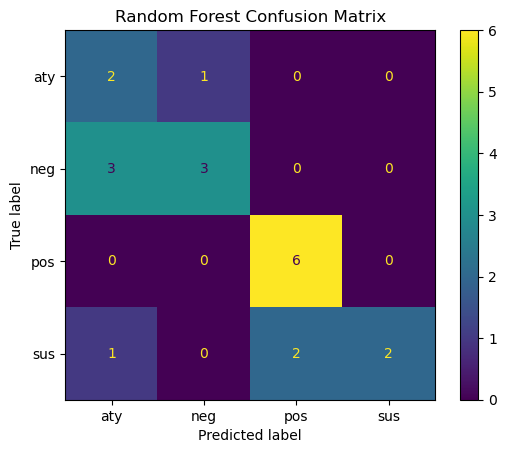

In [152]:
from sklearn.metrics import ConfusionMatrixDisplay

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Random Forest Confusion Matrix")
plt.show()

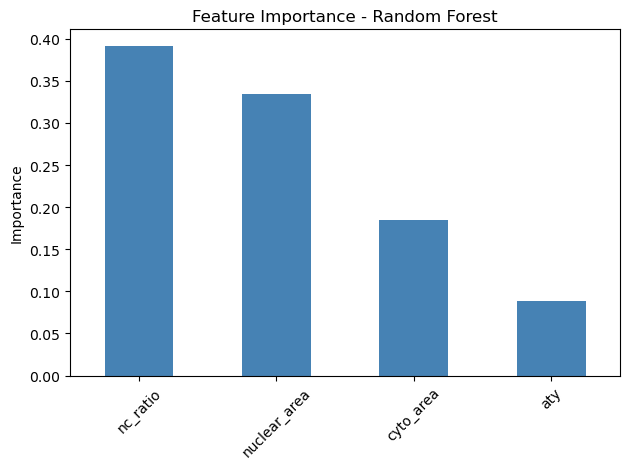

In [126]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=['aty', 'nc_ratio', 'nuclear_area', 'cyto_area']
).sort_values(ascending=False)

feature_importance.plot(kind='bar', color='steelblue')
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()